In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hashshamabid","key":"b135295876cbe9a5178d92010c8eb7c5"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 373kB/s]



In [4]:
!unzip sms-spam-collection-dataset.zip

Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


In [5]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [13]:
df

,spam,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [10]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.columns = ['spam', 'text']
df.head()

KeyError: "['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] not found in axis"

In [16]:
X = df['text']
y = df['spam']

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

vectorization = TfidfVectorizer()



x_train = vectorization.fit_transform(x_train)
x_test = vectorization.transform(x_test)

y_train = y_train.map({'spam':1,'ham':0})
y_test = y_test.map({'spam':1,'ham':0})

model = Pipeline([
    ("vectorization", TfidfVectorizer(lowercase=True,stop_words='english')),
    ("svm", LinearSVC())
])



In [17]:
model_svc = LinearSVC()
model_svc.fit(x_train,y_train)

model_lg = LogisticRegression()
model_lg.fit(x_train,y_train)

model_dtc = DecisionTreeClassifier()
model_dtc.fit(x_train,y_train)

model_rfc = RandomForestClassifier()
model_rfc.fit(x_train,y_train)

model_mnb = MultinomialNB()
model_mnb.fit(x_train,y_train)



MultinomialNB()

In [18]:
from sklearn.metrics import accuracy_score

predict_svc = model_svc.predict(x_test)
print("Accuracy of SVC is : ", accuracy_score(predict_svc,y_test))

predict_lg = model_lg.predict(x_test)
print("Accuracy of Logistic Regression is : ", accuracy_score(predict_lg,y_test))

predict_dtc = model_dtc.predict(x_test)
print("Accuracy of Decision Tree Classifier is : ", accuracy_score(predict_dtc,y_test))

predict_rfc = model_rfc.predict(x_test)
print("Accuracy of Random Forest Classifier is : ", accuracy_score(predict_rfc,y_test))

predict_mnb = model_mnb.predict(x_test)
print("Accuracy if MultinomialNB is : ", accuracy_score(predict_mnb,y_test))




Accuracy of SVC is :  0.9832535885167464
Accuracy of Logistic Regression is :  0.9659090909090909
Accuracy of Decision Tree Classifier is :  0.9659090909090909
Accuracy of Random Forest Classifier is :  0.9748803827751196
Accuracy if MultinomialNB is :  0.9599282296650717


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix : \n")
print(confusion_matrix(y_test,predict_svc))
print("------------------------------------------------")
print("Classification Report : \n")
print(classification_report(y_test,predict_svc))

Confusion Matrix : 

[[1450    3]
 [  25  194]]
------------------------------------------------
Classification Report : 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1453
           1       0.98      0.89      0.93       219

    accuracy                           0.98      1672
   macro avg       0.98      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



In [21]:
## Trying to improve the model

model_svc_improve = LinearSVC(class_weight='balanced')
model_svc_improve.fit(x_train,y_train)

predict_svc_improve = model_svc_improve.predict(x_test)

print("Accuracy of SVC is : ", accuracy_score(predict_svc_improve,y_test))
print("Confusion Matrix : \n")
print(confusion_matrix(y_test,predict_svc_improve))
print("------------------------------------------------")
print("Classification Report : \n")
print(classification_report(y_test,predict_svc_improve))


pipeline_svc_improve = Pipeline([
    # ("vectorization", TfidfVectorizer(stop_words='english',ngram_range=(1,2))),
    ("svc", LinearSVC(class_weight='balanced'))
])

pipeline_svc_improve.fit(x_train,y_train)

Accuracy of SVC is :  0.9844497607655502
Confusion Matrix : 

[[1449    4]
 [  22  197]]
------------------------------------------------
Classification Report : 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1453
           1       0.98      0.90      0.94       219

    accuracy                           0.98      1672
   macro avg       0.98      0.95      0.96      1672
weighted avg       0.98      0.98      0.98      1672



Pipeline(steps=[('svc', LinearSVC(class_weight='balanced'))])

In [22]:
import joblib
joblib.dump(model_svc_improve,'spam_model.pkl')
joblib.dump(vectorization,'vectorizer.pkl')
joblib.dump(pipeline_svc_improve,'pipeline.pkl')

['pipeline.pkl']

In [24]:
## Now i am testing the model

loaded = joblib.load('spam_model.pkl')
vectorization = joblib.load('vectorizer.pkl')
loaded_pipeline = joblib.load('pipeline.pkl')

sample_word_test = ["Congratulation! You Won a free Prize, Click now", "Wow! 2500 you won, need to sign to get the reward"]

# print(loaded_pipeline.predict(sample_word_test))

X_new = vectorization.transform(sample_word_test)

print(loaded.predict(X_new))




[1 0]


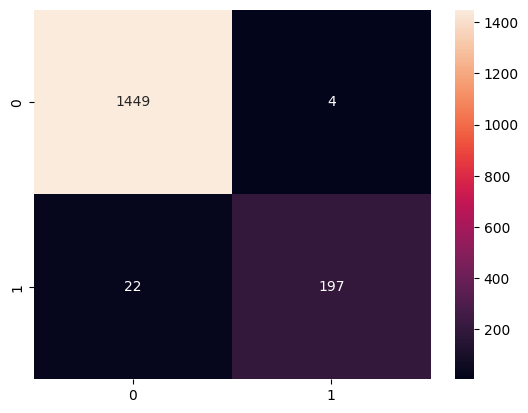

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(confusion_matrix(y_test,predict_svc_improve),annot=True,fmt='d')
plt.show()

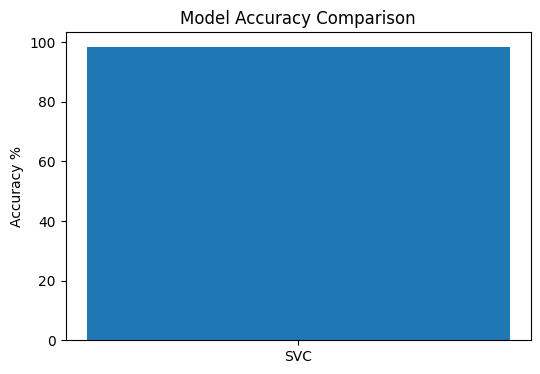

In [26]:
models = ["SVC"]
accuracy = [98.44]

plt.figure(figsize=(6,4))
plt.bar(models,accuracy)

plt.ylabel("Accuracy %")
plt.title("Model Accuracy Comparison")

plt.show()